In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


Create a simulated non-linear dataset

In [32]:
np.random.seed(777)

In [33]:
X = np.arange(-5,5,0.2).reshape(-1,1) # independent variable (feature
y = 0.5*X**2 + X + 2 + np.random.randn(len(X), 1)*3 # dependent variable (target)

this must show a non-linear relationship

In [34]:
print("Sample data points (X, y):")

for i in range(5):
    print(f"({X[i][0]:.2f}, {y[i][0]:.2f})")

Sample data points (X, y):
(-5.00, 8.10)
(-4.80, 6.25)
(-4.60, 7.78)
(-4.40, 5.14)
(-4.20, 9.34)


2. split the data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [36]:
print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples. ")

Data split: 35 training samples, 15 testing samples. 


3. Create a PolynomialFeatures instance to transform the data

In [37]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

4. Train the linear regression model on the transformed data

In [38]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


5. Make predictions on the transformed testing

In [39]:
y_pred = model.predict(X_test_poly)
print("Sample predictions:")
for i in range(min(5, len(y_test))):
    print(f"True: {y_test[i][0]:.2f}, Predicted: {y_pred[i][0]:.2f}")

Sample predictions:
True: -1.73, Predicted: 2.70
True: 10.49, Predicted: 8.95
True: 6.38, Predicted: 3.91
True: 11.82, Predicted: 13.99
True: 0.36, Predicted: 2.01


6. Evaluate the performance of the model

In [40]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [41]:
print("Model Evaluation:")
print(f"Mean squared error: {mse:.2f}")
print(f"R^2 score: {r2:.2f}")

Model Evaluation:
Mean squared error: 12.36
R^2 score: 0.61


7. Visualize

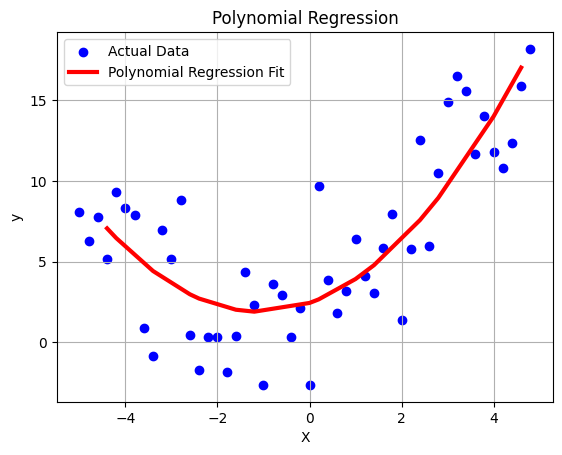


Visualization complete. The plot shows the original data points and the best-fit curve.


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Sort X_test and predictions for a smooth curve
sort_axis = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_axis]
y_pred_sorted = y_pred[sort_axis]

# Plot \
plt.scatter(X, y, color='blue', label='Actual Data')

# Plot polynomial regression
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=3, label='Polynomial Regression Fit')

plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print("\nVisualization complete. The plot shows the original data points and the best-fit curve.")
